# Análisis exploratorio — demanda de productos

Demanda agregada a partir de pedidos e ítems: patrones temporales, categorías, productos con mayor y menor volumen, valores atípicos en ventas diarias y correlaciones entre variables numéricas codificadas.

In [5]:
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import holidays

warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Configurar rutas
DATA_DIR = Path('data')


## 1. Carga y limpieza

Unión de pedidos e ítems.

In [6]:
orders_df = pd.read_csv(DATA_DIR / 'orders.csv')
order_items_df = pd.read_csv(DATA_DIR / 'order-items.csv')

orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
order_items_df['order_date'] = pd.to_datetime(order_items_df['order_date'])

demanda_df = order_items_df.merge(
    orders_df[['order_id', 'order_time', 'day_of_week', 'hour_of_day',
               'branch_id', 'branch_name', 'delivery_type', 'delivery_zone_id']],
    on='order_id',
    how='left',
    suffixes=('', '_orders')
)

if 'order_date' not in demanda_df.columns:
    raise ValueError(f"Falta order_date tras el merge. Columnas: {list(demanda_df.columns)}")

In [7]:
demanda_df['fecha_completa'] = pd.to_datetime(
    demanda_df['order_date'].astype(str) + ' ' + demanda_df['order_time'].astype(str)
)

demanda_expandida = demanda_df.loc[demanda_df.index.repeat(demanda_df['quantity'])].copy()
demanda_expandida['cantidad_vendida'] = 1

ve_holidays = holidays.Venezuela(years=[2025, 2026])
demanda_expandida['es_festivo'] = demanda_expandida['order_date'].apply(
    lambda x: 'Sí' if x in ve_holidays else 'No'
)

demanda_expandida['mes'] = demanda_expandida['order_date'].dt.month
demanda_expandida['trimestre'] = demanda_expandida['order_date'].dt.quarter
demanda_expandida['año'] = demanda_expandida['order_date'].dt.year

demanda_expandida['es_fin_semana'] = demanda_expandida['day_of_week'].apply(
    lambda x: 'Sí' if x in ['Saturday', 'Sunday'] else 'No'
)

demanda_expandida['promocion_activa'] = 'No'
demanda_expandida['temperatura'] = np.nan

## 2. Estadísticas Descriptivas por Producto

In [8]:
# Estadísticas por producto
stats_productos = demanda_expandida.groupby(['product_id', 'product_name', 'category_name']).agg({
    'cantidad_vendida': ['count', 'sum'],
    'product_price': 'mean',
    'item_subtotal': 'mean'
}).reset_index()

stats_productos.columns = ['product_id', 'product_name', 'category_name',
                           'total_ventas', 'cantidad_total', 'precio_promedio', 'subtotal_promedio']

stats_productos = stats_productos.sort_values('total_ventas', ascending=False)

cols = ['product_name', 'category_name', 'total_ventas', 'precio_promedio']
display(stats_productos[cols].head(10))
display(stats_productos[cols].tail(10))
stats_productos['precio_promedio'].describe()

,product_name,category_name,total_ventas,precio_promedio
19,Papas Fritas,Papas,15183,1.638677
45,Cheese Burger,Hamburguesas,6859,3.496282
50,Triple K,Hamburguesas,6046,8.171465
44,Bacon,Hamburguesas,4170,7.197139
39,Single Bacon,Hamburguesas,3707,4.717445
14,Doble Cheese Burger,Hamburguesas,3340,5.198674
34,COB,Hamburguesas,1792,7.139509
49,Chicken Cheese,Hamburguesas,1729,4.754772
26,K2,Perros calientes,1658,2.500000
25,K2,Pepitos,1517,2.484838


,product_name,category_name,total_ventas,precio_promedio
11,Golden de manzana 1Lt,Bebidas,66,3.000000
35,Chinotto Lata,Bebidas,41,2.000000
38,Mini cheeseburger PROMO 5x10€,Hamburguesas,37,10.000000
43,Pepito Standart,Pepitos,14,8.926429
0,Frescolita 2Lt,Bebidas,14,4.000000
7,tequeños,Hamburguesas,13,3.000000
36,Cheese Burger mini PROMO,Hamburguesas,6,10.000000
30,Hit de Naranja 1.5Lt,Bebidas,5,3.400000
13,Pepito Premium,Pepitos,2,7.990000
32,Chinotto 2Lt,Bebidas,2,4.000000


,precio_promedio
count,53.000000
mean,5.184419
std,2.776192
min,1.500000
25%,3.000000
50%,4.000000
75%,7.254609
max,12.367155


## 3. Análisis Temporal

### 3.1. Distribución por Día de la Semana

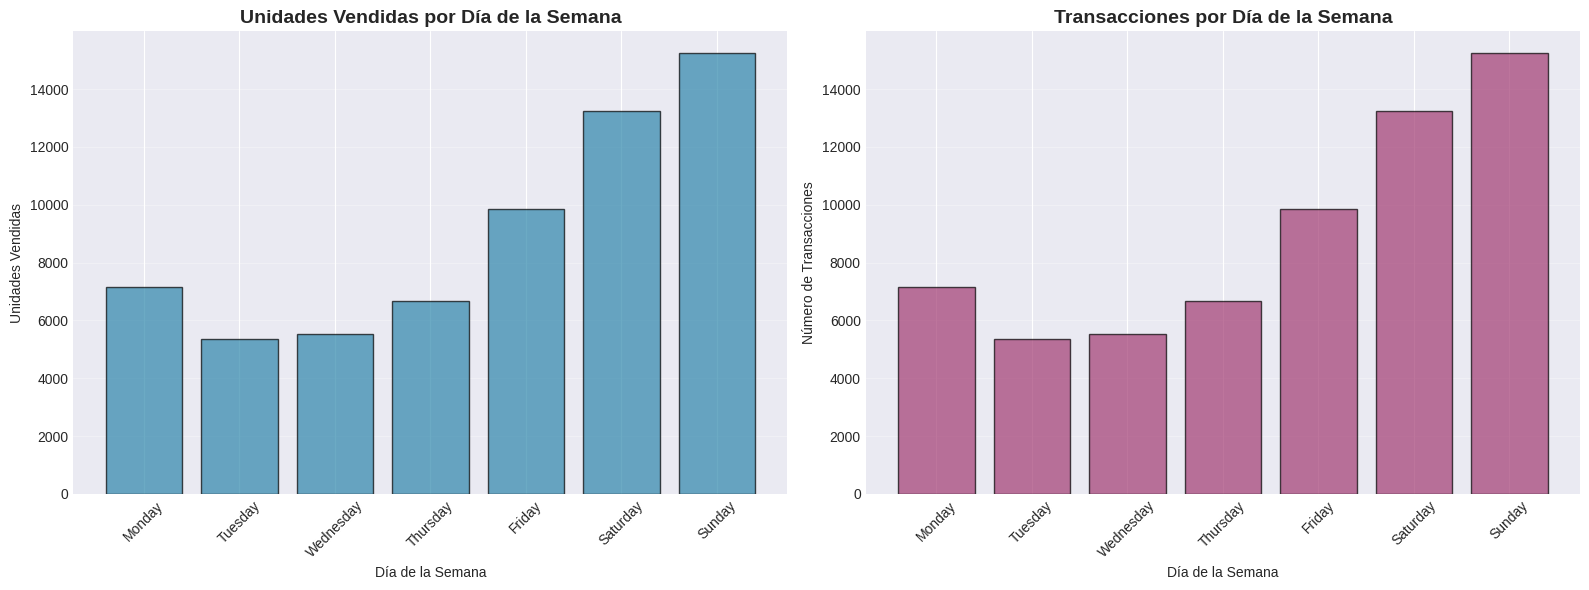

In [9]:
# Análisis por día de semana
dia_semana_stats = demanda_expandida.groupby('day_of_week').agg({
    'cantidad_vendida': 'sum',
    'product_id': 'count'
}).reset_index()
dia_semana_stats.columns = ['dia_semana', 'unidades_vendidas', 'transacciones']

# Ordenar por día de semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dia_semana_stats['dia_orden'] = pd.Categorical(dia_semana_stats['dia_semana'], categories=day_order, ordered=True)
dia_semana_stats = dia_semana_stats.sort_values('dia_orden')

dia_semana_stats[['dia_semana', 'unidades_vendidas', 'transacciones']]

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(range(len(dia_semana_stats)), dia_semana_stats['unidades_vendidas'],
            color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0].set_title('Unidades Vendidas por Día de la Semana', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Día de la Semana')
axes[0].set_ylabel('Unidades Vendidas')
axes[0].set_xticks(range(len(dia_semana_stats)))
axes[0].set_xticklabels(dia_semana_stats['dia_semana'], rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(range(len(dia_semana_stats)), dia_semana_stats['transacciones'],
            color='#A23B72', edgecolor='black', alpha=0.7)
axes[1].set_title('Transacciones por Día de la Semana', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Número de Transacciones')
axes[1].set_xticks(range(len(dia_semana_stats)))
axes[1].set_xticklabels(dia_semana_stats['dia_semana'], rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ventas_por_dia_semana.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.2. Distribución por Hora del Día

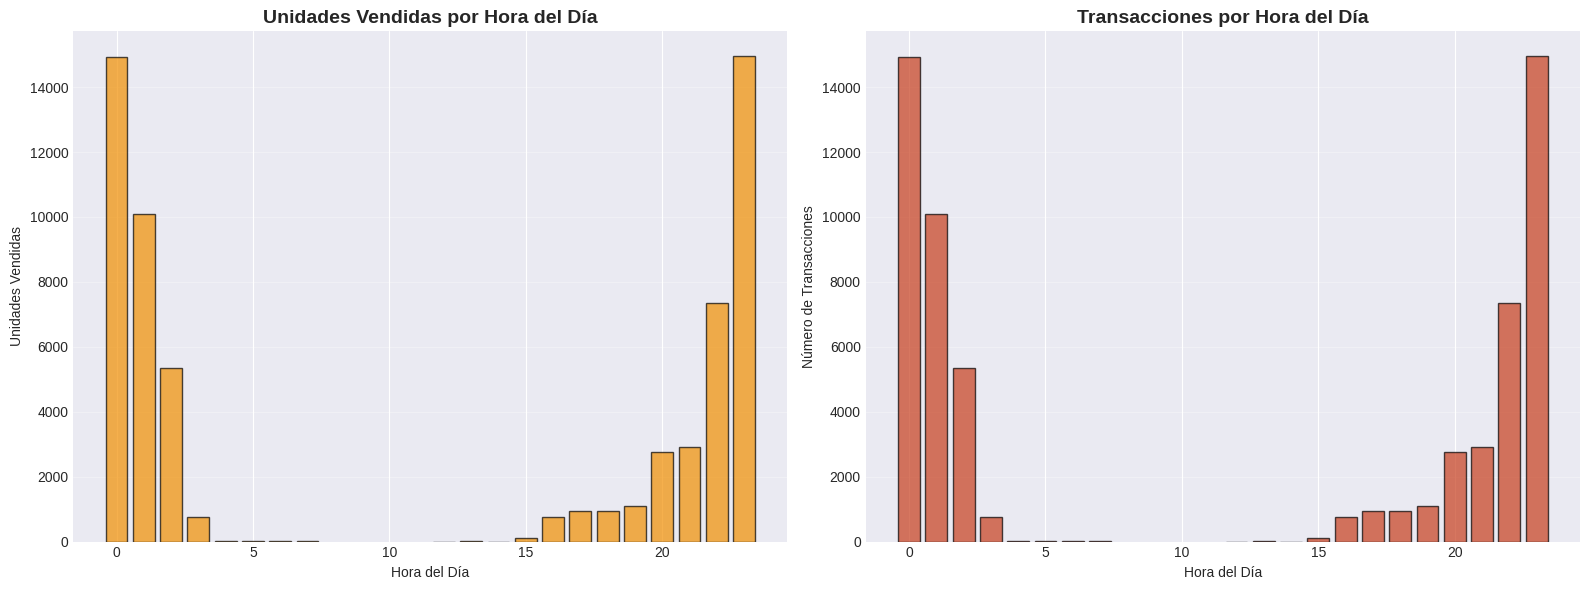

In [10]:
# Análisis por hora del día
hora_stats = demanda_expandida.groupby('hour_of_day').agg({
    'cantidad_vendida': 'sum',
    'product_id': 'count'
}).reset_index()
hora_stats.columns = ['hora', 'unidades_vendidas', 'transacciones']
hora_stats = hora_stats.sort_values('hora')

hora_stats.loc[hora_stats['unidades_vendidas'].idxmax()]

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(hora_stats['hora'], hora_stats['unidades_vendidas'],
            color='#F18F01', edgecolor='black', alpha=0.7, width=0.8)
axes[0].set_title('Unidades Vendidas por Hora del Día', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hora del Día')
axes[0].set_ylabel('Unidades Vendidas')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(hora_stats['hora'], hora_stats['transacciones'],
            color='#C73E1D', edgecolor='black', alpha=0.7, width=0.8)
axes[1].set_title('Transacciones por Hora del Día', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hora del Día')
axes[1].set_ylabel('Número de Transacciones')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ventas_por_hora.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.3. Tendencias Mensuales

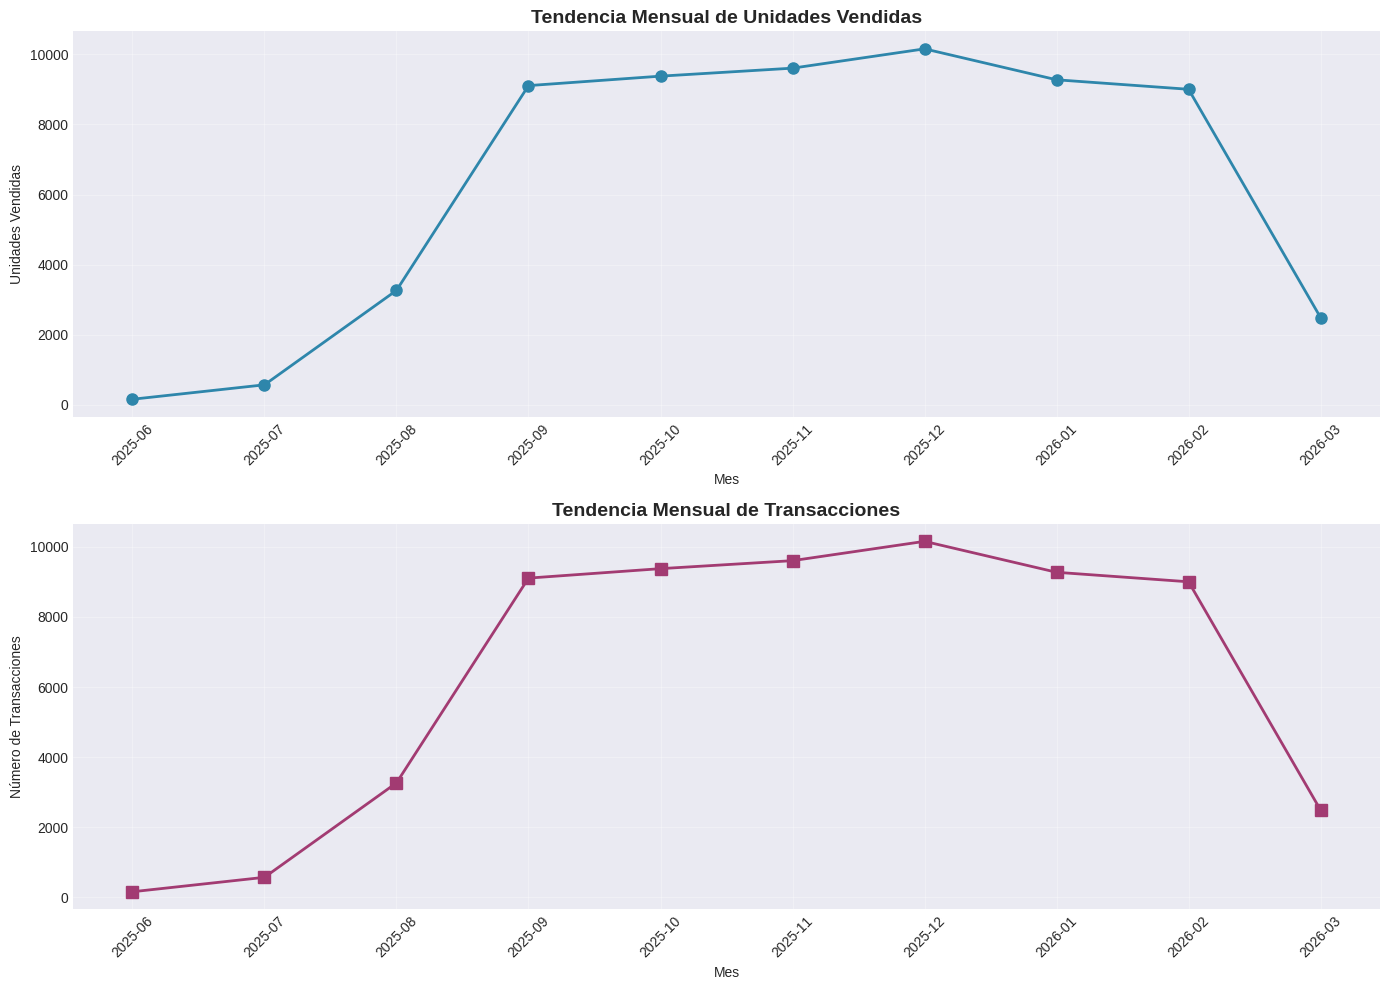

In [11]:
# Análisis por mes
mes_stats = demanda_expandida.groupby(['año', 'mes']).agg({
    'cantidad_vendida': 'sum',
    'product_id': 'count',
    'order_date': ['min', 'max']
}).reset_index()
mes_stats.columns = ['año', 'mes', 'unidades_vendidas', 'transacciones', 'fecha_min', 'fecha_max']
# Crear mes_nombre usando formato string directamente
mes_stats['mes_nombre'] = mes_stats.apply(
    lambda row: f"{int(row['año'])}-{int(row['mes']):02d}", axis=1
)
mes_stats = mes_stats.sort_values(['año', 'mes'])

mes_stats[['mes_nombre', 'unidades_vendidas', 'transacciones']]

# Visualización
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Serie temporal de unidades vendidas
axes[0].plot(mes_stats['mes_nombre'], mes_stats['unidades_vendidas'],
             marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0].set_title('Tendencia Mensual de Unidades Vendidas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Unidades Vendidas')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Serie temporal de transacciones
axes[1].plot(mes_stats['mes_nombre'], mes_stats['transacciones'],
             marker='s', linewidth=2, markersize=8, color='#A23B72')
axes[1].set_title('Tendencia Mensual de Transacciones', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Número de Transacciones')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('tendencia_mensual.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.4. Análisis de Estacionalidad y Patrones

unidades_vendidas        transacciones
                           mean    sum          mean
es_fin_semana                                       
No                       187.74  34545        187.74
Sí                       384.65  28464        384.65

unidades_vendidas        transacciones
                        mean    sum          mean
es_festivo                                       
No                     242.3  59607         242.3
Sí                     283.5   3402         283.5

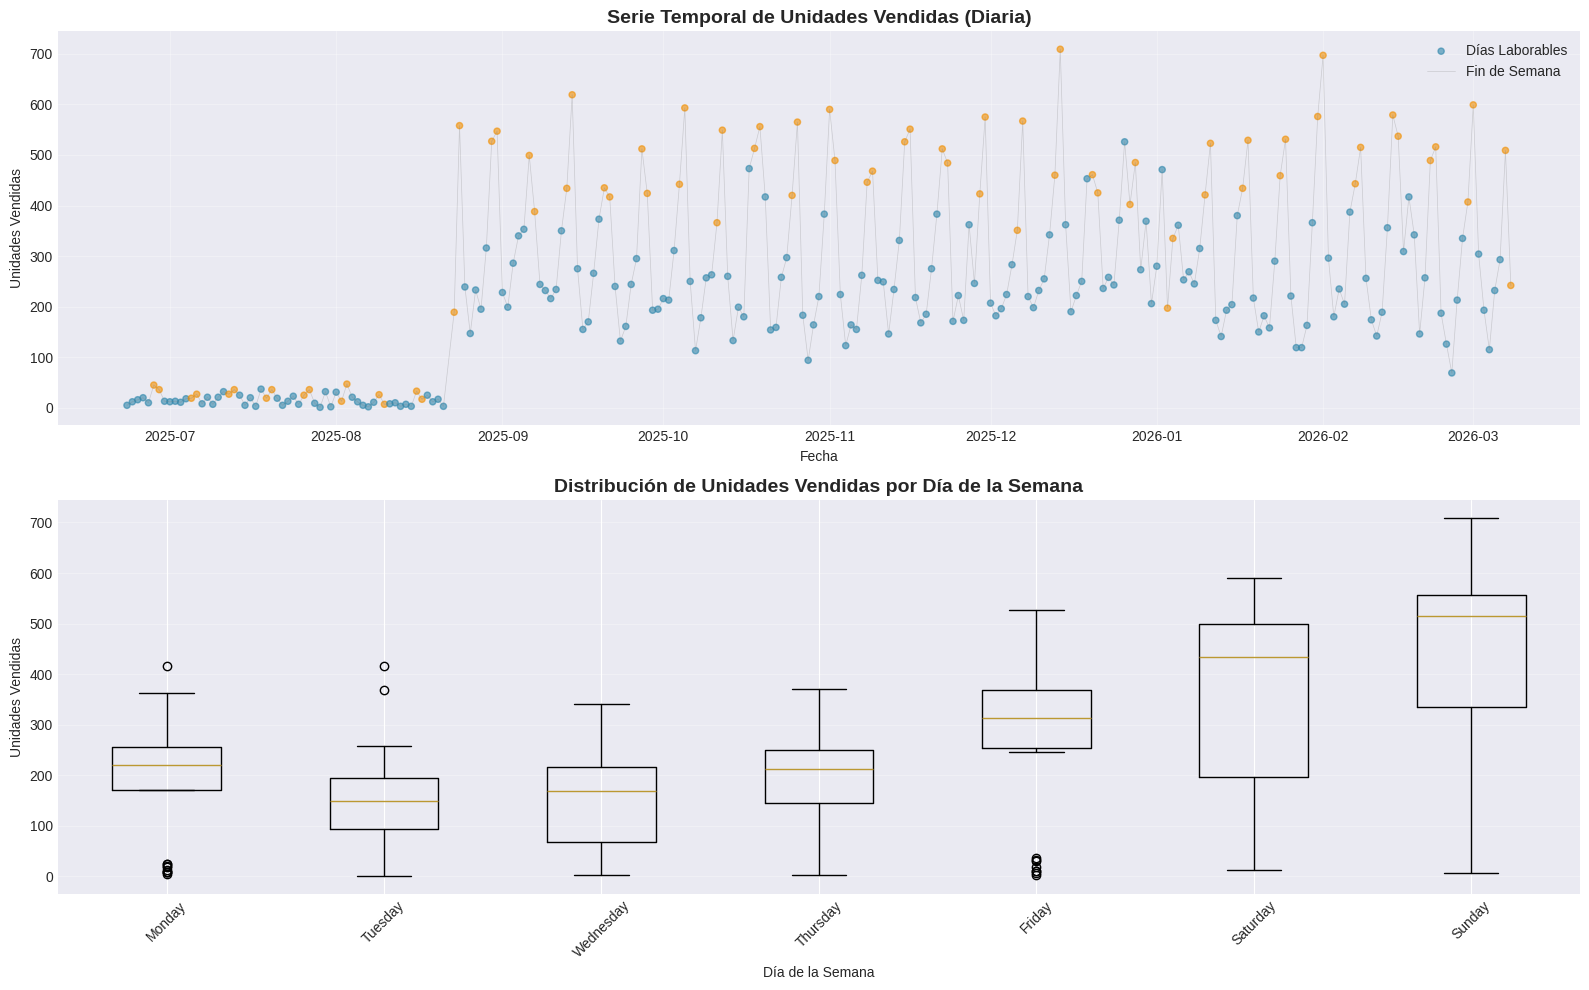

In [12]:
# Análisis de estacionalidad: ventas diarias
ventas_diarias = demanda_expandida.groupby('order_date').agg({
    'cantidad_vendida': 'sum',
    'product_id': 'count'
}).reset_index()
ventas_diarias.columns = ['fecha', 'unidades_vendidas', 'transacciones']
ventas_diarias = ventas_diarias.sort_values('fecha')

# Agregar información de día de semana y festivos
ventas_diarias['dia_semana'] = ventas_diarias['fecha'].dt.day_name()
ventas_diarias['es_festivo'] = ventas_diarias['fecha'].apply(
    lambda x: 'Sí' if x in ve_holidays else 'No'
)
ventas_diarias['es_fin_semana'] = ventas_diarias['dia_semana'].apply(
    lambda x: 'Sí' if x in ['Saturday', 'Sunday'] else 'No'
)

fin_semana_stats = ventas_diarias.groupby('es_fin_semana').agg({
    'unidades_vendidas': ['mean', 'sum'],
    'transacciones': 'mean'
}).round(2)
festivo_stats = ventas_diarias.groupby('es_festivo').agg({
    'unidades_vendidas': ['mean', 'sum'],
    'transacciones': 'mean'
}).round(2)
display(fin_semana_stats)
display(festivo_stats)

# Visualización de serie temporal diaria
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Serie temporal con colores por fin de semana
colors = ['#2E86AB' if x == 'No' else '#F18F01' for x in ventas_diarias['es_fin_semana']]
axes[0].scatter(ventas_diarias['fecha'], ventas_diarias['unidades_vendidas'],
                c=colors, alpha=0.6, s=20)
axes[0].plot(ventas_diarias['fecha'], ventas_diarias['unidades_vendidas'],
             linewidth=0.5, alpha=0.3, color='gray')
axes[0].set_title('Serie Temporal de Unidades Vendidas (Diaria)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Unidades Vendidas')
axes[0].grid(True, alpha=0.3)
axes[0].legend(['Días Laborables', 'Fin de Semana'])

# Boxplot por día de semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_diarias['dia_orden'] = pd.Categorical(ventas_diarias['dia_semana'], categories=day_order, ordered=True)
ventas_ordenadas = ventas_diarias.sort_values('dia_orden')

box_data = [ventas_ordenadas[ventas_ordenadas['dia_semana'] == day]['unidades_vendidas'].values
            for day in day_order]
axes[1].boxplot(box_data, labels=day_order)
axes[1].set_title('Distribución de Unidades Vendidas por Día de la Semana', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Unidades Vendidas')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('estacionalidad.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Análisis por Categorías

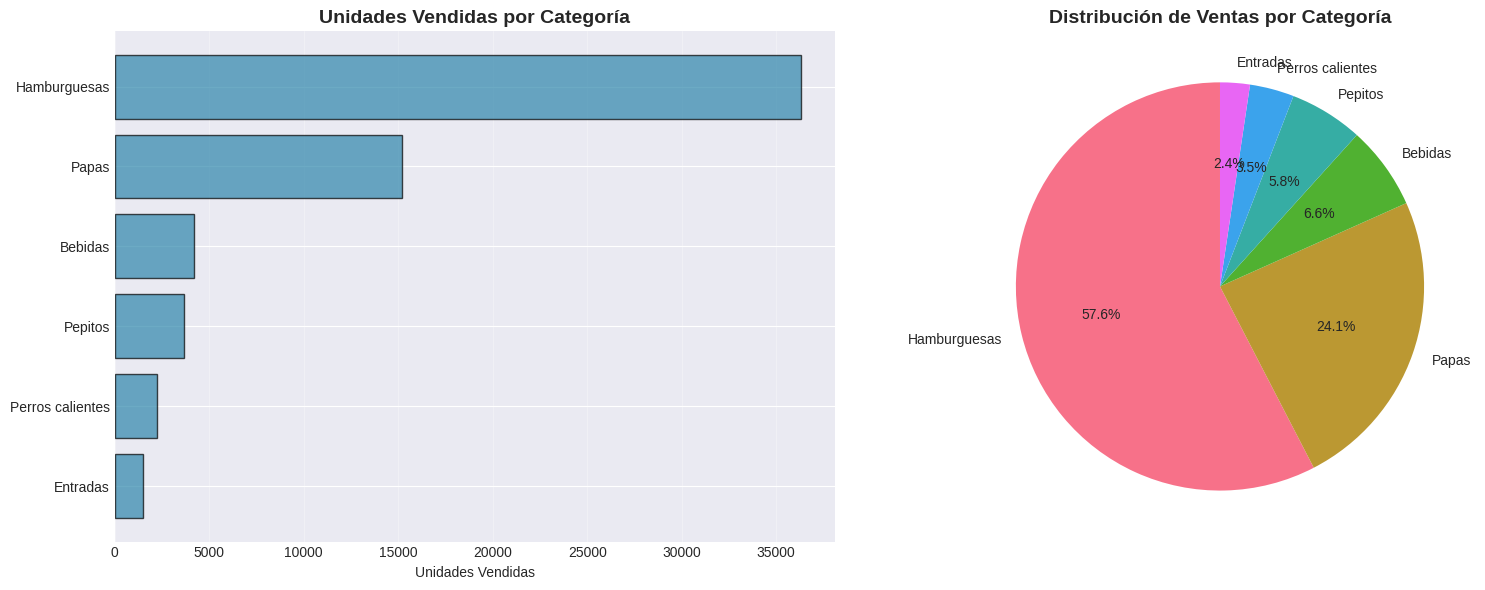

In [13]:
# Análisis por categoría
categoria_stats = demanda_expandida.groupby('category_name').agg({
    'cantidad_vendida': 'sum',
    'product_id': 'nunique',
    'product_price': 'mean'
}).reset_index()
categoria_stats.columns = ['categoria', 'unidades_vendidas', 'productos_unicos', 'precio_promedio']
categoria_stats = categoria_stats.sort_values('unidades_vendidas', ascending=False)
categoria_stats['porcentaje'] = (categoria_stats['unidades_vendidas'] / categoria_stats['unidades_vendidas'].sum() * 100).round(2)

categoria_stats

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
axes[0].barh(range(len(categoria_stats)), categoria_stats['unidades_vendidas'],
             color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(categoria_stats)))
axes[0].set_yticklabels(categoria_stats['categoria'])
axes[0].set_title('Unidades Vendidas por Categoría', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Unidades Vendidas')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Gráfico de pastel
axes[1].pie(categoria_stats['unidades_vendidas'], labels=categoria_stats['categoria'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribución de Ventas por Categoría', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('ventas_por_categoria.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Productos Más y Menos Vendidos

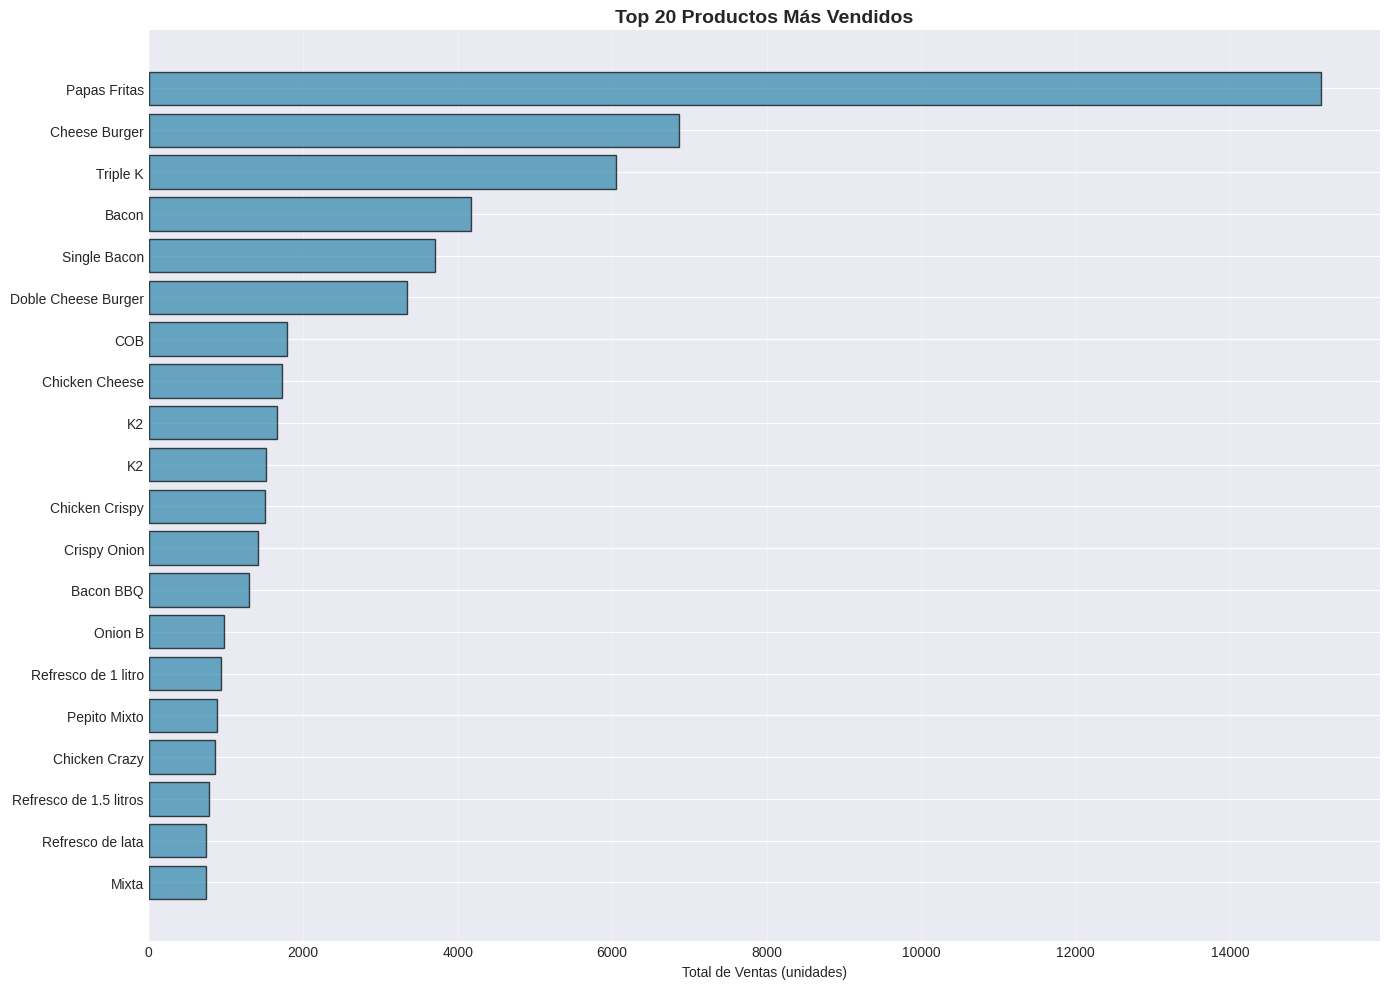

In [14]:
# Top 20 productos más vendidos
top_productos = stats_productos.head(20)

top_productos[['product_name', 'category_name', 'total_ventas', 'precio_promedio']]

# Visualización
fig, axes = plt.subplots(1, 1, figsize=(14, 10))
axes.barh(range(len(top_productos)), top_productos['total_ventas'],
          color='#2E86AB', edgecolor='black', alpha=0.7)
axes.set_yticks(range(len(top_productos)))
axes.set_yticklabels(top_productos['product_name'])
axes.set_title('Top 20 Productos Más Vendidos', fontsize=14, fontweight='bold')
axes.set_xlabel('Total de Ventas (unidades)')
axes.grid(True, alpha=0.3, axis='x')
axes.invert_yaxis()

plt.tight_layout()
plt.savefig('top_productos.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Detección de Valores Atípicos

,unidades_vendidas
count,258.000000
mean,244.220930
std,176.115217
min,1.000000
25%,119.000000
50%,226.000000
75%,368.250000
max,709.000000


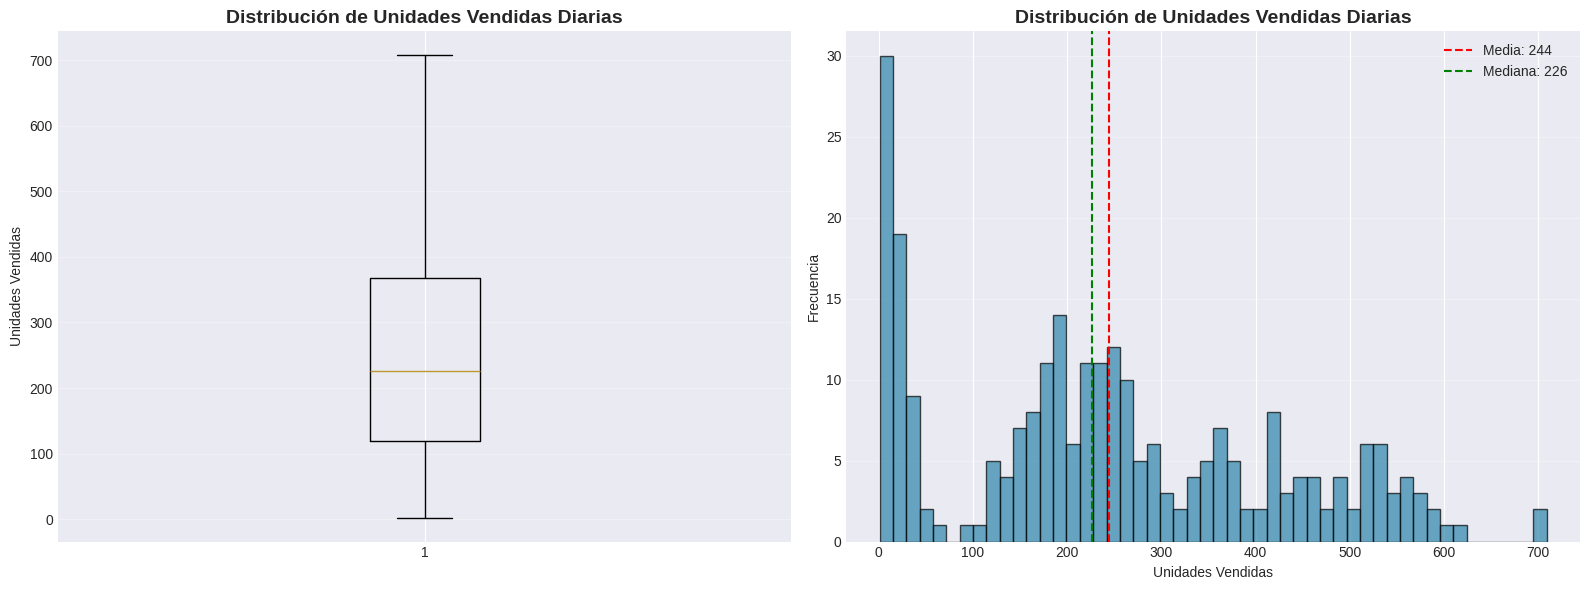

In [15]:
# Detección de valores atípicos en ventas diarias
from scipy import stats

# Calcular Z-scores para detectar outliers
ventas_diarias['z_score'] = np.abs(stats.zscore(ventas_diarias['unidades_vendidas']))
outliers = ventas_diarias[ventas_diarias['z_score'] > 3]

display(ventas_diarias['unidades_vendidas'].describe())
if len(outliers) > 0:
    display(outliers[['fecha', 'unidades_vendidas', 'dia_semana', 'es_festivo', 'z_score']])

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
axes[0].boxplot(ventas_diarias['unidades_vendidas'], vert=True)
axes[0].set_title('Distribución de Unidades Vendidas Diarias', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Unidades Vendidas')
axes[0].grid(True, alpha=0.3, axis='y')

# Histograma
axes[1].hist(ventas_diarias['unidades_vendidas'], bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
axes[1].axvline(ventas_diarias['unidades_vendidas'].mean(), color='red', linestyle='--',
                label=f'Media: {ventas_diarias["unidades_vendidas"].mean():.0f}')
axes[1].axvline(ventas_diarias['unidades_vendidas'].median(), color='green', linestyle='--',
                label=f'Mediana: {ventas_diarias["unidades_vendidas"].median():.0f}')
axes[1].set_title('Distribución de Unidades Vendidas Diarias', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Unidades Vendidas')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outliers.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Análisis de Correlaciones

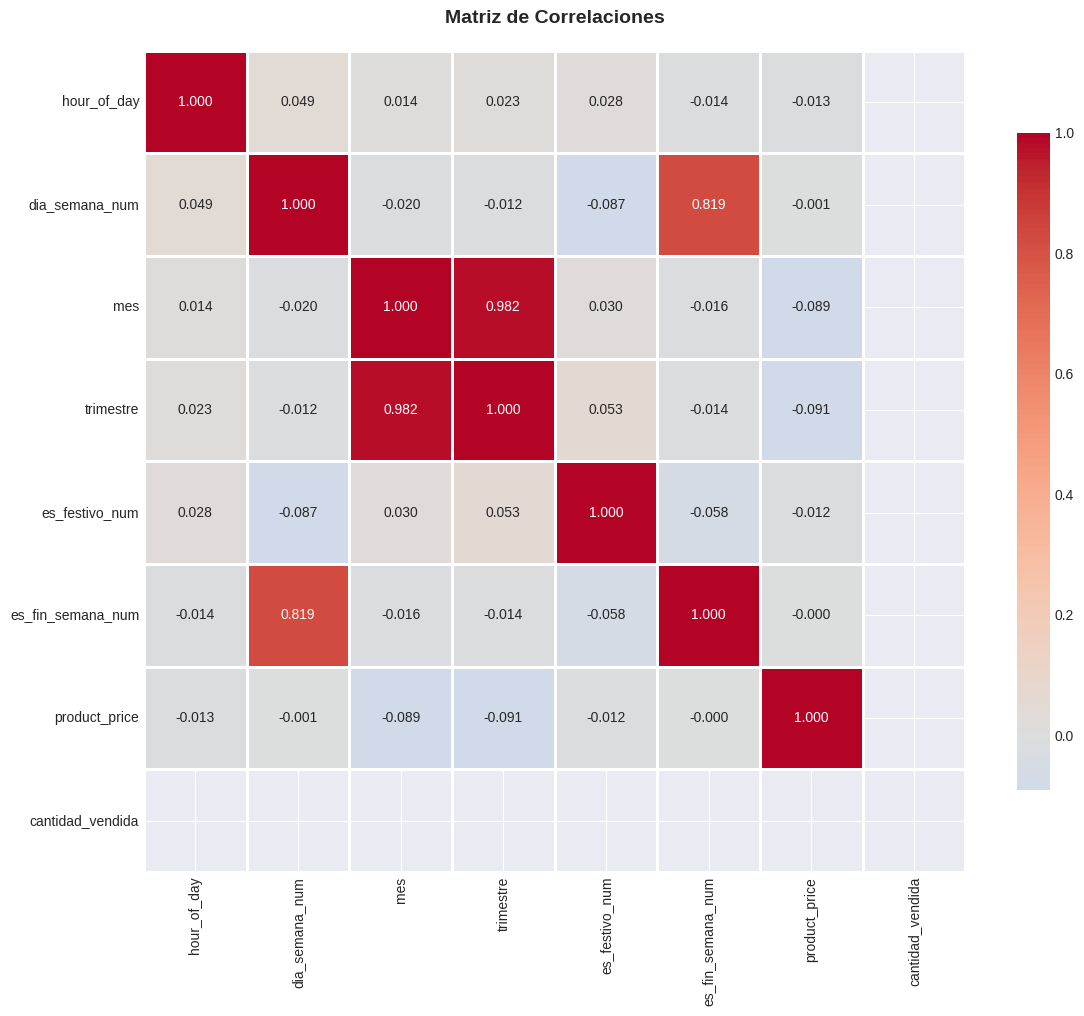

In [16]:
# Preparar datos para análisis de correlación
corr_data = demanda_expandida.copy()

# Codificar variables categóricas para correlación
corr_data['dia_semana_num'] = corr_data['day_of_week'].map({
    'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4,
    'Friday': 5, 'Saturday': 6, 'Sunday': 7
})
corr_data['es_festivo_num'] = corr_data['es_festivo'].map({'Sí': 1, 'No': 0})
corr_data['es_fin_semana_num'] = corr_data['es_fin_semana'].map({'Sí': 1, 'No': 0})

# Seleccionar variables numéricas para correlación
corr_vars = ['hour_of_day', 'dia_semana_num', 'mes', 'trimestre',
             'es_festivo_num', 'es_fin_semana_num', 'product_price',
             'cantidad_vendida']
corr_matrix = corr_data[corr_vars].corr()

# Visualización
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlaciones', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('matriz_correlaciones.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Agregación y exportación

`demanda_expandida`: una fila por unidad; columnas principales del ítem y del pedido (`order_date`, `order_time`, `product_id`, `product_name`, `category_id`, `category_name`, `day_of_week`, `hour_of_day`, `cantidad_vendida`, `es_festivo`, `es_fin_semana`, `mes`, `trimestre`, `año`, `promocion_activa`, `temperatura`, precios, sucursal y zona de entrega).

La celda siguiente agrupa por fecha, producto y dimensiones operativas y escribe `datos_demanda_productos_limpio.csv` en `data/`.

In [17]:
dataset_modelado = demanda_expandida.groupby([
    'order_date', 'product_id', 'product_name', 'category_id', 'category_name',
    'day_of_week', 'hour_of_day', 'mes', 'trimestre', 'es_festivo',
    'es_fin_semana', 'promocion_activa', 'branch_id', 'delivery_zone_id'
]).agg({
    'cantidad_vendida': 'sum',
    'product_price': 'mean'
}).reset_index()

dataset_modelado.columns = [
    'fecha', 'producto_id', 'producto_nombre', 'categoria_id', 'categoria_nombre',
    'dia_semana', 'hora', 'mes', 'trimestre', 'es_festivo',
    'es_fin_semana', 'promocion_activa', 'sucursal_id', 'zona_entrega',
    'cantidad_vendida', 'precio_unitario'
]

dataset_modelado['temperatura'] = np.nan

dataset_modelado = dataset_modelado[[
    'fecha', 'producto_id', 'producto_nombre', 'cantidad_vendida',
    'dia_semana', 'hora', 'es_festivo', 'promocion_activa', 'temperatura',
    'categoria_id', 'categoria_nombre', 'precio_unitario', 'sucursal_id', 'zona_entrega'
]]

output_path = DATA_DIR / 'datos_demanda_productos_limpio.csv'
dataset_modelado.to_csv(output_path, index=False)
dataset_modelado.head(10)

,fecha,producto_id,producto_nombre,cantidad_vendida,dia_semana,hora,es_festivo,promocion_activa,temperatura,categoria_id,categoria_nombre,precio_unitario,sucursal_id,zona_entrega
0,2025-06-23,ZxiZc5Ysy2QtEHlkUa26,K2,1,Monday,22,No,No,NaN,QQPD1Ey9h8aSAm4lgzK4,Pepitos,2.0,jaPKtgb9591gZMkIAf4r,dadd8275-8c9a-4a79-a5d1-5b04f76c9668
1,2025-06-23,i4U27Q4HIMcUQQsgP8Ma,Bacon,1,Monday,22,No,No,NaN,3IVCqz38gInGGTAtnuQu,Hamburguesas,6.0,jaPKtgb9591gZMkIAf4r,dadd8275-8c9a-4a79-a5d1-5b04f76c9668
2,2025-06-23,uAVoHmUTVtuuCzd6GsTw,Chicken Cheese,2,Monday,23,No,No,NaN,3IVCqz38gInGGTAtnuQu,Hamburguesas,4.0,jaPKtgb9591gZMkIAf4r,c7fea292-ca0e-4060-8e35-218c062a3ecc
3,2025-06-23,w2hAFBPv9fhCTbCvhLXL,Triple K,1,Monday,22,No,No,NaN,3IVCqz38gInGGTAtnuQu,Hamburguesas,7.0,jaPKtgb9591gZMkIAf4r,dadd8275-8c9a-4a79-a5d1-5b04f76c9668
4,2025-06-24,8Byy9oiFFNNOSvJUtjqA,Chicken Crispy,1,Tuesday,1,Sí,No,NaN,3IVCqz38gInGGTAtnuQu,Hamburguesas,6.0,jaPKtgb9591gZMkIAf4r,5c7373cc-349d-41c0-a6ab-21f52fde6801
5,2025-06-24,Px1YgBnkrpPAtDB2jSI8,Papas Fritas,2,Tuesday,0,Sí,No,NaN,sz3XeCEKmcuGdqswyFtg,Papas,1.5,jaPKtgb9591gZMkIAf4r,3fc2453c-86c4-4402-85d6-b50e0edcb37a
6,2025-06-24,SWreoE3PRieS8U0BT592,Refresco de lata,2,Tuesday,0,Sí,No,NaN,HMrqD7wVX8lrHCZEK1Lb,Bebidas,2.0,jaPKtgb9591gZMkIAf4r,3fc2453c-86c4-4402-85d6-b50e0edcb37a
7,2025-06-24,YF6pZUVpfGGAqOfyzMiJ,Chicken Bacon,1,Tuesday,1,Sí,No,NaN,3IVCqz38gInGGTAtnuQu,Hamburguesas,5.0,jaPKtgb9591gZMkIAf4r,5c7373cc-349d-41c0-a6ab-21f52fde6801
8,2025-06-24,aaHWR5OA8qoTasqJDPH3,Pepito Lomito,1,Tuesday,0,Sí,No,NaN,QQPD1Ey9h8aSAm4lgzK4,Pepitos,9.5,jaPKtgb9591gZMkIAf4r,5c7373cc-349d-41c0-a6ab-21f52fde6801
9,2025-06-24,bUiK1TSociwcAISaztiu,Bacon BBQ,2,Tuesday,0,Sí,No,NaN,3IVCqz38gInGGTAtnuQu,Hamburguesas,6.0,jaPKtgb9591gZMkIAf4r,3fc2453c-86c4-4402-85d6-b50e0edcb37a
